# Compare surface winds with 100m

We want to establish if surface winds in climate models can be used directly or whether extrapolation to hub-height is necessary.

In [42]:
# client.close()
# cluster.close()

In [2]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

In [3]:
PROJECT = "dt6"

In [43]:
walltime = "00:10:00"
cores = 24
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/ob53+gdata/w42+scratch/w42+gdata/gb02+scratch/gb02+gdata/ng72+scratch/ng72+gdata/rt52"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/w42/dr6273/tmp/logs"
)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/bokeh/server/contexts.py:163: RuntimeWarning: coroutine 'WSHandler.send_message' was never awaited
  self._server_context = BokehServerContext(self)


In [44]:
cluster.scale(jobs=1)
client = Client(cluster)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB


In [45]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.122.2:35681,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
import xarray as xr

import glob

import matplotlib.pyplot as plt

In [8]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [9]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

In [10]:
YEARS = slice("1979", "2024")

### Load data

ERA5

In [11]:
era5_100m = xr.open_zarr(
    FILEPATH + "ERA5/ws100m_era5_daily_Aus.zarr",
    consolidated=True
)["ws100m"].sel(time=YEARS)

In [12]:
era5_10m = xr.open_zarr(
    FILEPATH + "ERA5/ws10m_era5_daily_Aus.zarr",
    consolidated=True
)["ws10m"].sel(time=YEARS)

In [13]:
era5_rez_mask = xr.open_dataset(
    '/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_era5_grid.nc'
)["REZ"]

In [14]:
era5_wind_mask = era5_rez_mask.where(era5_rez_mask.region_code_SC2050.isin([1, 2, 4, 5])).sum("region")

BARRA-R2

In [15]:
barraR2_100m = xr.open_mfdataset(
    glob.glob(FILEPATH + "BARRA-R2/*100m*")
)["ws100m"]

In [16]:
barraR2_10m = xr.open_mfdataset(
    glob.glob(FILEPATH + "BARRA-R2/wss*")
)["wss"]

In [18]:
barraR2_rez_mask = xr.open_dataset(
    '/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_BARRA-R2_grid.nc'
)["REZ"]

In [26]:
barraR2_rez_mask = barraR2_rez_mask.assign_coords(
    region_code_SC2050=("region", era5_rez_mask.region_code_SC2050.values)
)

In [27]:
barraR2_wind_mask = barraR2_rez_mask.where(
    barraR2_rez_mask.region_code_SC2050.isin([1, 2, 4, 5])
).sum("region")

### Compare

Correlation

In [28]:
era5_corr = xr.corr(era5_100m, era5_10m, dim="time").compute()

In [29]:
era5_corr_DJF = xr.corr(
    fn.sel_month(era5_100m, [12, 1, 2]),
    fn.sel_month(era5_10m, [12, 1, 2]),
    dim="time"
).compute()

In [30]:
era5_corr_JJA = xr.corr(
    fn.sel_month(era5_100m, [6, 7, 8]),
    fn.sel_month(era5_10m, [6, 7, 8]),
    dim="time"
).compute()

In [31]:
barraR2_corr = xr.corr(barraR2_100m, barraR2_10m, dim="time").compute()

In [32]:
barraR2_corr_DJF = xr.corr(
    fn.sel_month(barraR2_100m, [12, 1, 2]),
    fn.sel_month(barraR2_10m, [12, 1, 2]),
    dim="time"
).compute()

In [33]:
barraR2_corr_JJA = xr.corr(
    fn.sel_month(barraR2_100m, [6, 7, 8]),
    fn.sel_month(barraR2_10m, [6, 7, 8]),
    dim="time"
).compute()

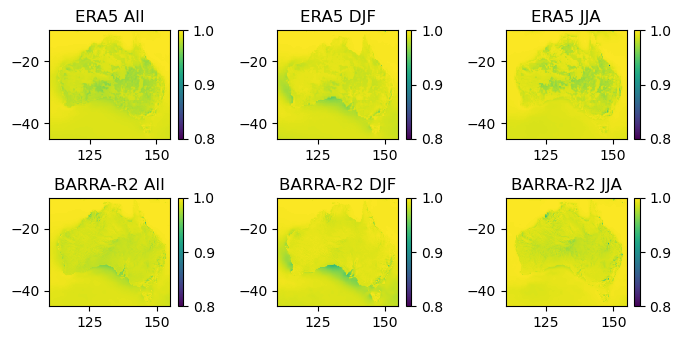

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(7,3.5))

vmin = 0.8

era5_corr.plot(ax=ax[0,0], vmin=vmin, vmax=1)
ax[0,0].set_title("ERA5 All")

era5_corr_DJF.plot(ax=ax[0,1], vmin=vmin, vmax=1)
ax[0,1].set_title("ERA5 DJF")

era5_corr_JJA.plot(ax=ax[0,2], vmin=vmin, vmax=1)
ax[0,2].set_title("ERA5 JJA")

barraR2_corr.plot(ax=ax[1,0], vmin=vmin, vmax=1)
ax[1,0].set_title("BARRA-R2 All")

barraR2_corr_DJF.plot(ax=ax[1,1], vmin=vmin, vmax=1)
ax[1,1].set_title("BARRA-R2 DJF")

barraR2_corr_JJA.plot(ax=ax[1,2], vmin=vmin, vmax=1)
ax[1,2].set_title("BARRA-R2 JJA")

for a in ax.flatten():
    a.set_ylabel("")
    a.set_xlabel("")
plt.tight_layout()

Overlap of drought days

In [35]:
era5_100m_dr = xr.where(
    era5_100m < era5_100m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


In [36]:
era5_10m_dr = xr.where(
    era5_10m < era5_10m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(


In [37]:
barraR2_100m_dr = xr.where(
    barraR2_100m < barraR2_100m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 46
  result = blockwise(


In [38]:
barraR2_10m_dr = xr.where(
    barraR2_10m < barraR2_10m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 46
  result = blockwise(


In [39]:
def concurrent_droughts(da1, da2):
    con = da1 + da2
    return (con.where(con == 2).count("time") / len(con["time"]))

In [46]:
era5_con = concurrent_droughts(era5_100m_dr, era5_10m_dr).compute()
barraR2_con = concurrent_droughts(barraR2_100m_dr, barraR2_10m_dr).compute()

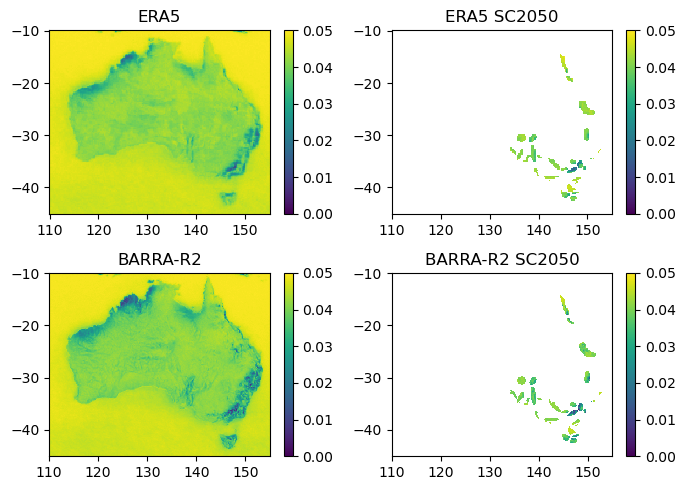

In [47]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))

vmin = 0
vmax = 0.05

era5_con.plot(ax=ax[0,0], vmin=vmin, vmax=vmax)
ax[0,0].set_title("ERA5")

era5_con.where(era5_wind_mask).plot(ax=ax[0,1], vmin=vmin, vmax=vmax)
ax[0,1].set_title("ERA5 SC2050")

barraR2_con.plot(ax=ax[1,0], vmin=vmin, vmax=vmax)
ax[1,0].set_title("BARRA-R2")

barraR2_con.where(barraR2_wind_mask).plot(ax=ax[1,1], vmin=vmin, vmax=vmax)
ax[1,1].set_title("BARRA-R2 SC2050")

for a in ax.flatten():
    a.set_ylabel("")
    a.set_xlabel("")
plt.tight_layout()